In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder
import xgboost as xgb
from xgboost import XGBClassifier
from sklearn.model_selection import TimeSeriesSplit

In [3]:
df = pd.read_csv(r"C:\Ki_4\Domain Banking\Financial Transactions\Big_Query_Fetched.csv")
df.head()

,id,date,client_id,card_id,amount,use_chip,merchant_id,merchant_city,merchant_state,zip,...,errors,target,current_age,gender,yearly_income,total_debt,credit_score,card_brand,card_type,mcc_description
0,16029274,2015-05-01 14:58:00,1492,4818,364.79,Online Transaction,60152,ONLINE,Online/International,Online/International,...,No Error,1,63,Female,56635,13015,786,Visa,Credit,Steelworks
1,16402126,2015-07-20 10:00:00,1542,2906,183.56,Online Transaction,5594,ONLINE,Online/International,Online/International,...,No Error,1,46,Female,55565,34039,731,Mastercard,Debit (Prepaid),Steel Products Manufacturing
2,17222818,2016-01-11 17:26:00,277,4264,25.44,Online Transaction,30497,ONLINE,Online/International,Online/International,...,No Error,1,46,Male,31739,81905,799,Mastercard,Debit,Coated and Laminated Products
3,8465827,2010-09-03 07:06:00,1699,2204,614.71,Online Transaction,47203,ONLINE,Online/International,Online/International,...,No Error,1,67,Female,52929,37514,737,Visa,Debit,Steel Drums and Barrels
4,20952333,2018-03-15 17:47:00,517,106,466.13,Chip Transaction,47203,Rome,Italy,Online/International,...,No Error,1,33,Male,24009,19085,811,Mastercard,Credit,Steel Drums and Barrels


In [4]:
df.isnull().sum()

id                 0
date               0
client_id          0
card_id            0
amount             0
use_chip           0
merchant_id        0
merchant_city      0
merchant_state     0
zip                0
mcc                0
errors             0
target             0
current_age        0
gender             0
yearly_income      0
total_debt         0
credit_score       0
card_brand         0
card_type          0
mcc_description    0
dtype: int64

In [7]:
num_cols = ['amount', 'current_age', 'yearly_income', 'total_debt', 'credit_score']

quantiles_df = df[num_cols].describe(percentiles=[0.10, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99]).T
display(quantiles_df)

,count,mean,std,min,10%,25%,50%,75%,90%,95%,99%,max
amount,113332.0,51.011845,108.265102,-500.0,1.76,9.48,31.85,71.0,122.42,179.8935,423.7473,4978.45
current_age,113332.0,54.257447,15.733996,23.0,35.00,43.00,52.00,64.0,78.00,84.0000,92.0000,101.00
yearly_income,113332.0,46355.373469,24412.788261,1.0,26511.00,32576.00,40867.00,53702.0,70673.00,87030.0000,141161.0000,280199.00
total_debt,113332.0,57378.984250,51937.544510,0.0,1433.00,16040.00,51428.00,84507.0,119670.00,146608.0000,231619.0000,461854.00
credit_score,113332.0,713.867443,65.598973,488.0,625.00,684.00,716.00,756.0,792.00,814.0000,850.0000,850.00


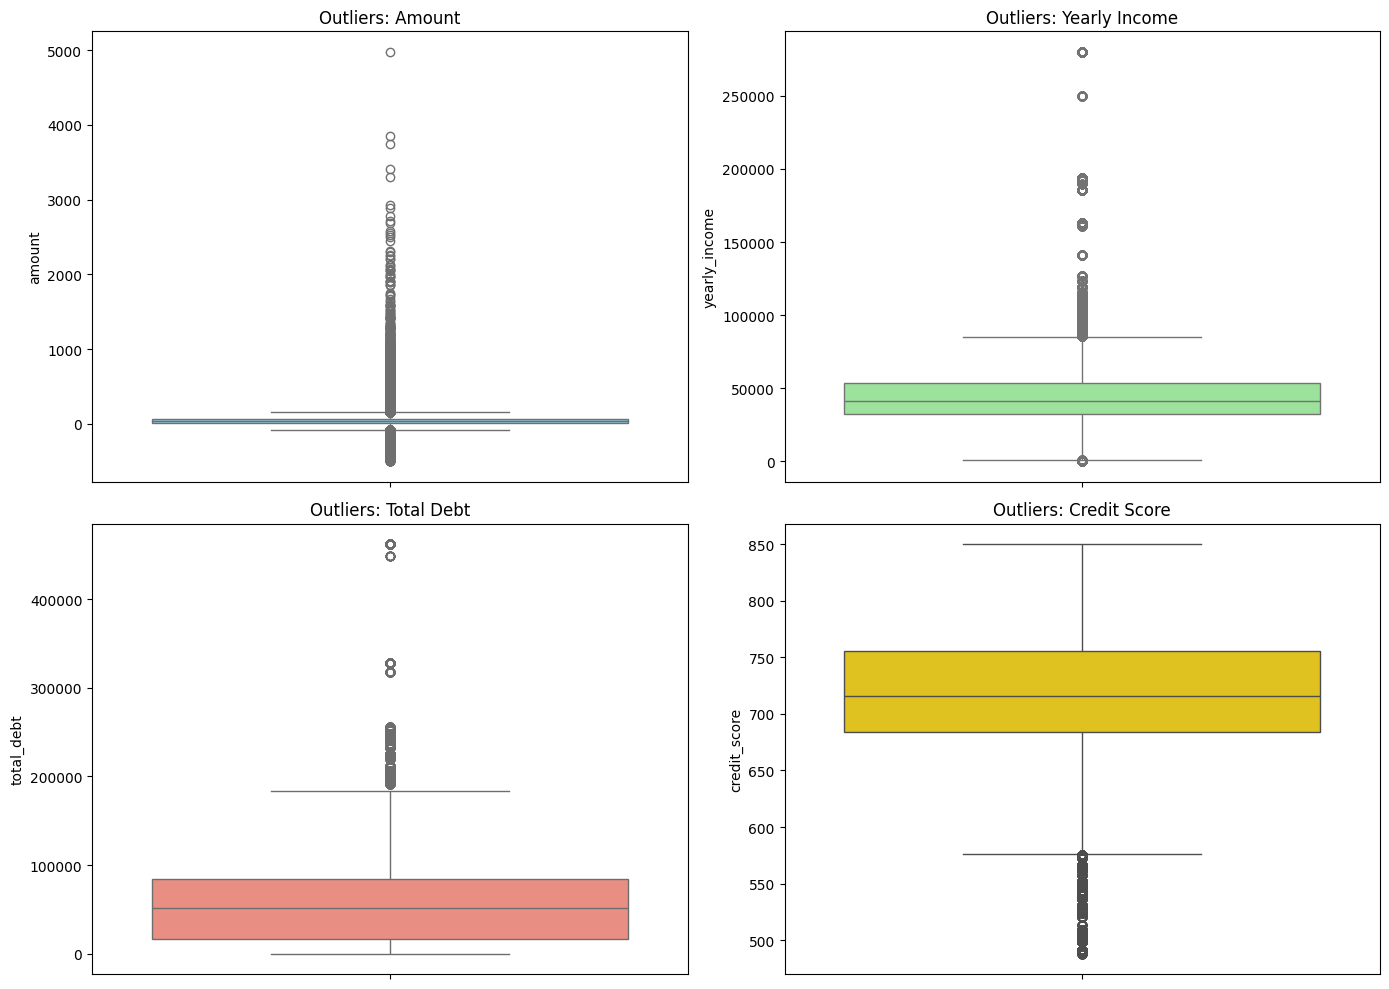

In [8]:

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

sns.boxplot(y=df['amount'], ax=axes[0, 0], color='skyblue')
axes[0, 0].set_title('Outliers: Amount')

sns.boxplot(y=df['yearly_income'], ax=axes[0, 1], color='lightgreen')
axes[0, 1].set_title('Outliers: Yearly Income')

sns.boxplot(y=df['total_debt'], ax=axes[1, 0], color='salmon')
axes[1, 0].set_title('Outliers: Total Debt')

sns.boxplot(y=df['credit_score'], ax=axes[1, 1], color='gold')
axes[1, 1].set_title('Outliers: Credit Score')

plt.tight_layout()
plt.show()

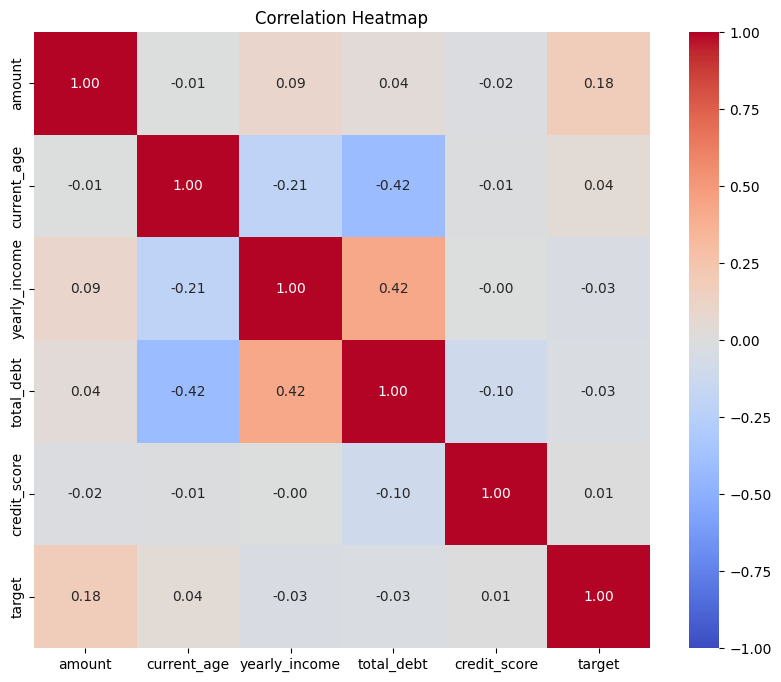

In [10]:
plt.figure(figsize=(10, 8))

corr_matrix = df[num_cols + ['target']].corr(method='spearman')

sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', vmin=-1, vmax=1, center=0, square=True)
plt.title('Correlation Heatmap')
plt.show()

C:\Users\Admin\AppData\Local\Temp\ipykernel_23848\2527591240.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=cardinality.values, y=cardinality.index, palette='viridis')


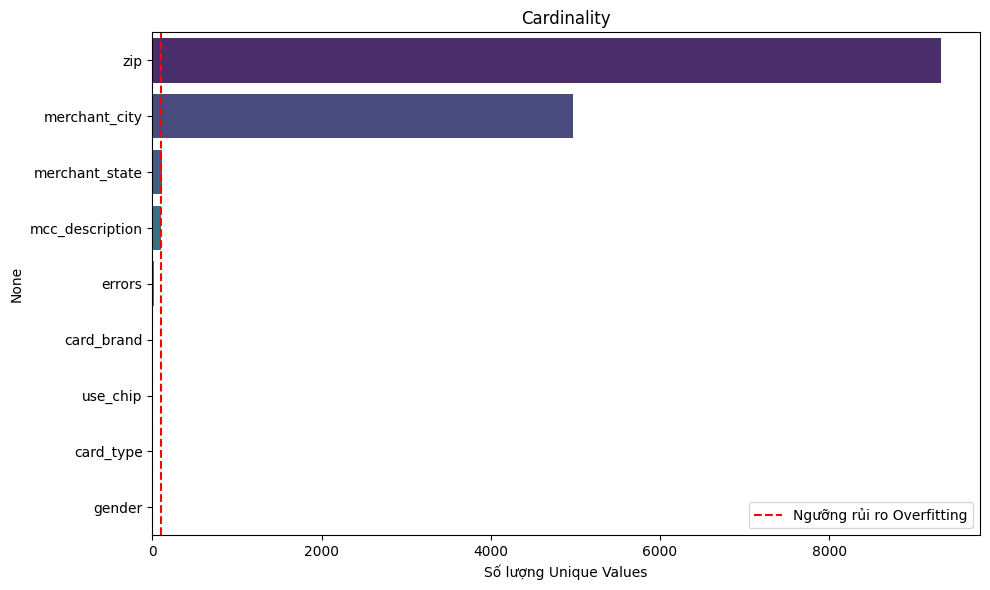

In [11]:
cat_cols = df.select_dtypes(include=['object', 'string', 'category']).columns
cardinality = df[cat_cols].nunique().sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=cardinality.values, y=cardinality.index, palette='viridis')
plt.title('Cardinality')
plt.xlabel('Số lượng Unique Values')
plt.axvline(x=100, color='red', linestyle='--', label='Ngưỡng rủi ro Overfitting')
plt.legend()
plt.tight_layout()
plt.show()

C:\Users\Admin\AppData\Local\Temp\ipykernel_23848\1820035248.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=error_fraud_rate.values, y=error_fraud_rate.index, palette='Reds_r')


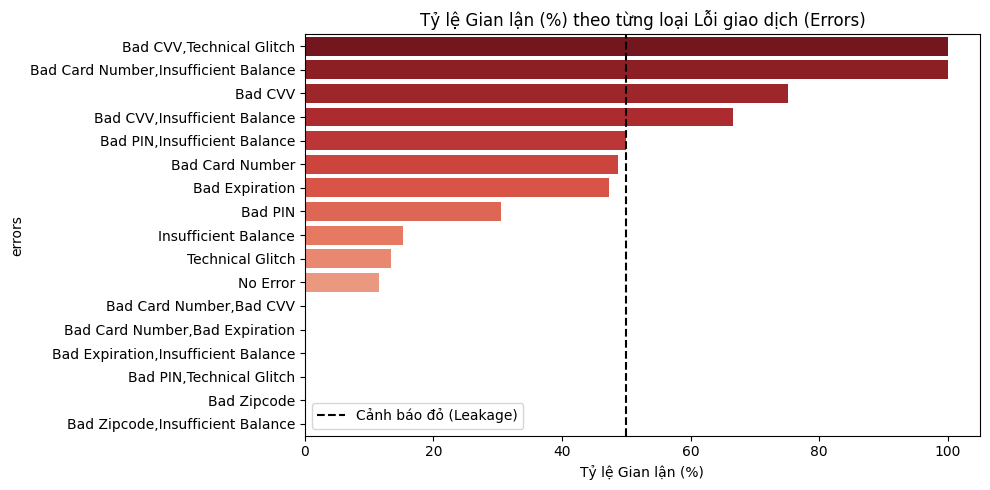

In [12]:
error_fraud_rate = df.groupby('errors')['target'].mean().sort_values(ascending=False) * 100

plt.figure(figsize=(10, 5))
sns.barplot(x=error_fraud_rate.values, y=error_fraud_rate.index, palette='Reds_r')
plt.title('Tỷ lệ Gian lận (%) theo từng loại Lỗi giao dịch (Errors)')
plt.xlabel('Tỷ lệ Gian lận (%)')
plt.axvline(x=50, color='black', linestyle='--', label='Cảnh báo đỏ (Leakage)')
plt.legend()
plt.tight_layout()
plt.show()

In [13]:
df = df.sort_values(by=['client_id', 'date']).reset_index(drop=True)

df['is_senior_50_plus'] = (df['current_age'] >= 50).astype(int)
df['dti_ratio'] = df['total_debt'] / (df['yearly_income'] + 1)
df['hour_risk_tier'] = df['hour'].apply(lambda h: 2 if 10 <= h <= 13 else (0 if 0 <= h <= 5 else 1))
df['amount_vs_monthly_income'] = df['amount'] / ((df['yearly_income'] / 12) + 1)

df = df.set_index('date')

df['trans_count_24h'] = df.groupby('client_id')['amount'].rolling('24h', closed='left').count().reset_index(level=0, drop=True).fillna(0)

df['trans_sum_24h'] = df.groupby('client_id')['amount'].rolling('24h', closed='left').sum().reset_index(level=0, drop=True).fillna(0)

avg_30d = df.groupby('client_id')['amount'].rolling('30d', closed='left').mean().reset_index(level=0, drop=True)
df['amount_vs_30d_avg'] = df['amount'] / (avg_30d + 1)
df['amount_vs_30d_avg'] = df['amount_vs_30d_avg'].fillna(0)

df = df.reset_index()

cat_cols = df.select_dtypes(include=['object', 'string']).columns
for col in cat_cols:
    df[col] = df[col].astype('category')

cols_to_drop = [
    'id', 'card_id', 'merchant_id', 'date', 
    'merchant_city', 'zip', 'mcc', 'merchant_state', 
    'mcc_description', 'use_chip', 'errors'
]
df = df.drop(columns=cols_to_drop)

In [ ]:
from sklearn.model_selection import GroupShuffleSplit


X = df.drop(columns=['target'])
y = df['target']
groups = df['client_id']


gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(X, y, groups=groups))


X_train = X.iloc[train_idx].drop(columns=['client_id'])
X_test = X.iloc[test_idx].drop(columns=['client_id'])
y_train = y.iloc[train_idx]
y_test = y.iloc[test_idx]


print("tap Train:", len(X_train))
print("tap Test: ", len(X_test))

tap Train: 91308
tap Test:  22024


In [ ]:
import numpy as np


X_train = X_train.replace([np.inf, -np.inf], 0)
X_test = X_test.replace([np.inf, -np.inf], 0)



Đã dọn sạch giá trị Vô cực. Dữ liệu sẵn sàng cho XGBoost!


In [ ]:
import numpy as np
from xgboost import XGBClassifier
from sklearn.metrics import average_precision_score


neg_class_count = (y_train == 0).sum()
pos_class_count = (y_train == 1).sum()
scale_weight = neg_class_count / pos_class_count


xgb_scale = XGBClassifier(
    random_state=42, 
    enable_categorical=True, 
    eval_metric='aucpr',
    tree_method='hist',
    scale_pos_weight=scale_weight
)
xgb_scale.fit(X_train, y_train)

preds_scale = xgb_scale.predict_proba(X_test)[:, 1]
pr_auc_scale = average_precision_score(y_test, preds_scale)


def focal_loss_obj(y_true, y_pred_logits):
    gamma = 2.0
    alpha = 0.25
    p = 1.0 / (1.0 + np.exp(-y_pred_logits))
    grad = (p - y_true) * ((alpha * y_true + (1 - alpha) * (1 - y_true)) * ((1 - p)**gamma * y_true + p**gamma * (1 - y_true)))
    hess = p * (1 - p) * ((alpha * y_true + (1 - alpha) * (1 - y_true)) * ((1 - p)**gamma * y_true + p**gamma * (1 - y_true)))
    return grad, hess


xgb_focal = XGBClassifier(
    random_state=42, 
    enable_categorical=True, 
    tree_method='hist',
    objective=focal_loss_obj
)
xgb_focal.fit(X_train, y_train)

logits_focal = xgb_focal.predict(X_test, output_margin=True)
preds_focal = 1.0 / (1.0 + np.exp(-logits_focal))
pr_auc_focal = average_precision_score(y_test, preds_focal)


print("-" * 50)

print("1.scale_pos_weight: ", round(pr_auc_scale, 4))
print("2. Focal Loss: ", round(pr_auc_focal, 4))
print("-" * 50)

--------------------------------------------------
KET QUA PR-AUC SAU KHI DUNG FEATURE ENGINEERING NGANG HANG:
1. Dung scale_pos_weight cua XGBoost:  0.7498
2. Dung Focal Loss tu code:            0.7188
--------------------------------------------------


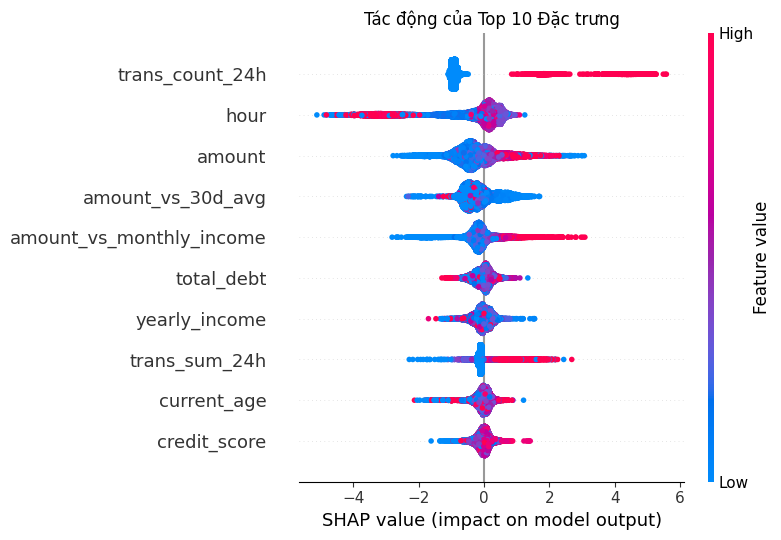

In [19]:
import shap
import matplotlib.pyplot as plt


explainer = shap.TreeExplainer(xgb_scale)
shap_values = explainer(X_test)


plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_test, max_display=10, show=False)
plt.title('Tác động của Top 10 Đặc trưng')
plt.tight_layout()
plt.show()

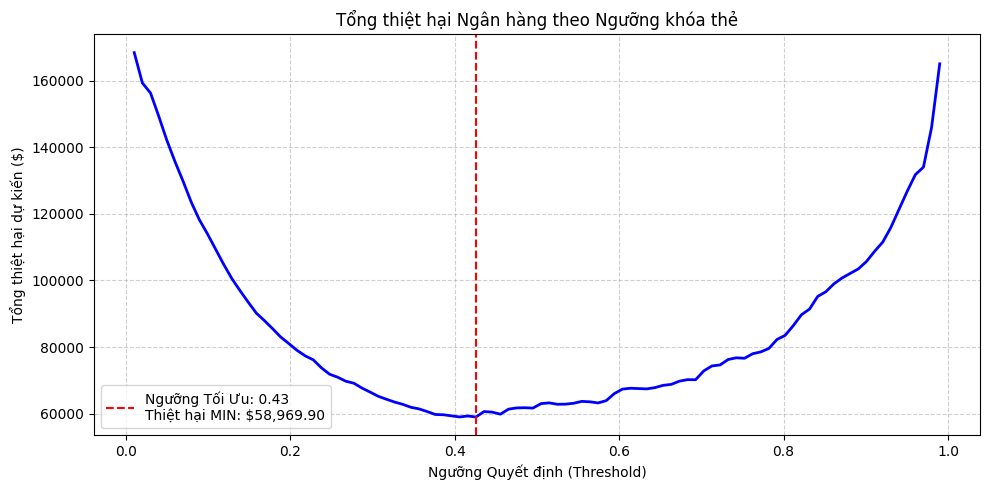

In [21]:

probabilities = xgb_scale.predict_proba(X_test)[:, 1]

amounts = X_test['amount'].values
y_true = y_test.values


thresholds = np.linspace(0.01, 0.99, 100)
costs = []


COST_FP = 10 
for thresh in thresholds:

    y_pred = (probabilities >= thresh).astype(int)
    

    fp_mask = (y_pred == 1) & (y_true == 0)
    total_fp_cost = np.sum(fp_mask) * COST_FP
    

    fn_mask = (y_pred == 0) & (y_true == 1)
    total_fn_cost = np.sum(amounts[fn_mask]) 
    

    total_cost = total_fp_cost + total_fn_cost
    costs.append(total_cost)


min_cost = min(costs)
best_threshold = thresholds[costs.index(min_cost)]


plt.figure(figsize=(10, 5))
plt.plot(thresholds, costs, color='blue', linewidth=2)
plt.axvline(x=best_threshold, color='red', linestyle='--', 
            label=f'Ngưỡng Tối Ưu: {best_threshold:.2f}\nThiệt hại MIN: ${min_cost:,.2f}')
plt.title('Tổng thiệt hại Ngân hàng theo Ngưỡng khóa thẻ')
plt.xlabel('Ngưỡng Quyết định (Threshold)')
plt.ylabel('Tổng thiệt hại dự kiến ($)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

